In [1]:
import os
import glob
import numpy as np
import pandas as pd
#import network_fcon as fc
import scipy as sp
from scipy.stats import pearsonr
from scipy.stats import linregress
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nilearn.datasets import fetch_atlas_schaefer_2018


In [18]:
# Set variables
dataset = 'longglucest_outputmeasures2'
atlas = 'Schaefer2018_1000Parcels_17Networks'
nmaps = ["NMDA", "mGluR5", "GABAa"]
maps = ["cest", "NMDA", "mGluR5", "GABA"]
normalize_cest = True
nmap_palette = {
    "NMDA": "Purples",   # Replace with actual nmap names and desired palettes
    "mGluR5": "Reds",
    "GABAa": "Greens",
    "SAaxis": "Oranges"
    # Add more mappings as needed
}

# Set paths
inpath = "/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps"
#outpath = "/Users/pecsok/Desktop/ImageData/PMACS_remote/data/nmaps/analyses/" + atlas
outpath = "/Users/pecsok/Library/CloudStorage/Box-Box/GluCEST PhD/Manuscripts/Neuromaps/analysis" + atlas


# Read in data
demo_df = pd.read_csv(os.path.join(inpath, 'Data', 'longglucest_demographics_102824.csv'))
grp_df = pd.read_csv(os.path.join(inpath, 'Data', 'trimmed_cestmatlongglucest_outputmeasures2Schaefer2018_1000Parcels_17Networks.csv'))
feature_df = pd.read_csv(os.path.join(inpath, 'Data', 'feature_data_all_scale1000_17.csv'))
receptor_df = pd.read_csv(os.path.join(inpath, 'Data', 'receptor_data_all_scale1000_17.csv'))

In [3]:
# Scrub data

# Step 1: Filter columns that contain "Subject", "group", or "NZMean" in their names
grp_df = grp_df.loc[:, grp_df.columns.str.contains("Subject|group|NZMean")]

# Step 2: Fix column names
grp_df.columns = grp_df.columns.str.replace(r"^X", "", regex=True)
grp_df.columns = grp_df.columns.str.replace(r" NZMean", "", regex=True)

# Step 4: Remove repeated Subjects and filter the DataFrame
filtered = (
    grp_df.assign(bblid=grp_df['Subject'].str.split("_").str[0])  # Extract part before '_'
    .drop_duplicates(subset='bblid', keep='first')  # Keep the first occurrence for each subject
    .query("group != ''")  # Filter out rows where 'group' is an empty string
)
filtered = filtered.drop(columns=["group", "bblid"])

# Step 2: Create a long-form dataframe using `melt`
long_df = pd.melt(
    filtered,
    id_vars=["Subject"],  # Columns to keep as is
    var_name="Parcel",    # New column for variable names
    value_name="GluCEST"  # New column for values
)

# Step 4: Merge with `demo_df` to add demographic data
long_df["BBLID"] = long_df["Subject"].str.split("_").str[0]  # Extract part before '_'
long_df["BBLID"] = long_df["BBLID"].astype(str)
demo_df["BBLID"] = demo_df["BBLID"].astype(str)
long_df = long_df.merge(
    demo_df[["BBLID", "Age_Enroll_Months", "Sex", "Group"]],
    on="BBLID",
    how="left"
)
long_df["Age"] = long_df["Age_Enroll_Months"] / 12
long_df["hstatus"] = long_df["Group"].apply(lambda x: "HC" if x == "TD/NC" else "PSY")

# Merge with feature_df
feature_df["SAaxis_rank"] = feature_df["SAaxis"].rank()
long_df = long_df.merge(
    feature_df[["Parcel", "abaPC1", "CBF", "CBV", "CThick", "Glucose", "O2met", "SAaxis", "SAaxis_rank"]],
    on="Parcel",
    how="left"
)

# Merge with receptor_df
long_df = long_df.merge(
    receptor_df[[
        "Parcel", "5HT1a", "5HT1b", "5HT2a", "5HT4", "5HT6", "5HTT", 
        "A4B2", "CB1", "D1", "D2", "DAT", "GABAa", "H3", "M1", 
        "mGluR5", "MOR", "NET", "NMDA", "VAChT"
    ]],
    on="Parcel",
    how="left"
)

# Make means_df
means_df_all = (
    long_df.groupby("Parcel", as_index=False)
    .agg({"GluCEST": lambda x: x.mean(skipna=True)})
)
means_df_all = means_df_all.merge(
    feature_df[["Parcel", "abaPC1", "CBF", "CBV", "CThick", "Glucose", "O2met", "SAaxis", "SAaxis_rank"]],
    on="Parcel",
    how="left"
)
means_df_all = means_df_all.merge(
    receptor_df[[
        "Parcel", "5HT1a", "5HT1b", "5HT2a", "5HT4", "5HT6", "5HTT", 
        "A4B2", "CB1", "D1", "D2", "DAT", "GABAa", "H3", "M1", 
        "mGluR5", "MOR", "NET", "NMDA", "VAChT"
    ]],
    on="Parcel",
    how="left"
)

In [6]:
means_df_all

,Parcel,GluCEST,abaPC1,CBF,CBV,CThick,Glucose,O2met,SAaxis,SAaxis_rank,...,D2,DAT,GABAa,H3,M1,mGluR5,MOR,NET,NMDA,VAChT
0,17Networks_RH_ContA_Cingm_1,7.500874,-1.141579,-1.551334,-1.528440,-2.078371,-0.997154,-1.218255,1.425176,901.0,...,-0.726387,31.853984,727.105326,17.467943,2.016986,-1.573938,19.297386,0.014441,5.481680,0.184995
1,17Networks_RH_ContA_Cingm_2,7.629877,-0.968025,-1.408439,-1.681353,-2.179363,-1.326730,-2.057701,1.101117,865.0,...,-1.028679,31.514892,720.207182,14.511598,1.864755,-1.450434,20.347334,-0.010844,5.378153,0.062506
2,17Networks_RH_ContB_PFCmp_1,7.411252,0.406100,0.908641,1.190660,0.574922,0.143459,1.018898,-0.424104,400.0,...,0.361841,29.255923,829.002803,23.280847,4.040718,1.540954,36.946402,0.059872,7.495800,0.067282
3,17Networks_RH_ContB_PFCmp_2,6.712910,0.035896,0.728813,0.500989,0.541661,-0.304859,0.608985,-1.196857,17.0,...,-0.235693,22.364719,678.018396,21.523964,3.789644,-0.024016,28.175165,-0.039549,6.293772,-0.147593
4,17Networks_RH_ContB_PFCmp_3,6.946444,0.023729,0.579373,0.894244,0.400743,-0.245867,0.796069,-0.894497,147.0,...,-0.024112,25.564300,767.517475,22.474048,3.844001,0.557950,30.568832,0.040900,6.817208,0.022565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,17Networks_RH_VisPeri_ExStrSup_3,8.564716,0.014126,1.507414,1.263967,0.974862,-0.395215,1.508835,1.584488,920.0,...,-0.331436,29.998501,1026.326728,19.593855,4.912053,1.201754,6.637480,0.083798,7.148766,0.056309
63,17Networks_RH_VisPeri_ExStrSup_4,8.777151,-0.531576,0.370956,0.977884,-0.234713,-0.860079,1.121042,0.551003,786.0,...,-0.518184,26.832134,854.969542,15.694498,4.422918,0.187993,1.878439,0.063313,7.233956,-0.080152
64,17Networks_RH_VisPeri_ExStrSup_7,8.572659,-0.125739,0.446873,0.699838,0.219828,-0.492288,1.191117,0.765574,821.0,...,-0.296192,27.457690,872.027378,17.723039,4.501956,0.649158,5.829361,0.073358,6.983315,-0.038287
65,17Networks_RH_VisPeri_StriCal_3,9.358720,-1.539434,2.602602,3.297119,0.652589,-1.465139,1.391103,0.772553,822.0,...,-0.931784,29.343938,1041.680309,16.899480,4.668038,-0.190620,0.000000,0.050702,7.618946,0.011467


In [7]:
# Create sliding window
num_rows = len(means_df_all)
window_size = 10
step_size = 3  # Adjust this value to control the spacing between windows
window_indices = [(start, start + window_size - 1) 
                  for start in range(0, num_rows - window_size + 1, step_size)]


# Sliding window loop
means_df_all = means_df_all.sort_values(by="SAaxis_rank", ascending=True)
means_df_all = means_df_all.reset_index(drop=True)
results = []
for start, end in window_indices:
    # Subset the dataframe for the current window
    window_df = means_df_all.iloc[start:end + 1]
    # Perform correlation using linregress
    slope, intercept, r_value, p_value, std_err = linregress(
        window_df["GluCEST"], window_df["NMDA"]
    )
    SAavg = window_df["SAaxis_rank"].median()
    # Save results for the current window
    results.append({
        "Window_Start": start,
        "Window_End": end,
        "R_squared": r_value**2,  # Square of the correlation coefficient
        "P_value": p_value,
        "SAaxis_rank": SAavg
    })
results_df = pd.DataFrame(results)
print(results_df)

    Window_Start  Window_End  R_squared   P_value  SAaxis_rank
0              0           9   0.037151  0.593684        134.0
1              3          12   0.294978  0.104713        231.5
2              6          15   0.406533  0.047345        290.0
3              9          18   0.203906  0.190184        322.5
4             12          21   0.020421  0.693704        381.0
5             15          24   0.093463  0.390320        417.0
6             18          27   0.062239  0.486984        506.5
7             21          30   0.112359  0.343731        596.0
8             24          33   0.001341  0.920000        668.0
9             27          36   0.015283  0.733663        710.0
10            30          39   0.328474  0.083284        742.0
11            33          42   0.475052  0.027469        772.0
12            36          45   0.547306  0.014446        793.5
13            39          48   0.588429  0.009614        811.0
14            42          51   0.489925  0.024222      

In [11]:
# Assuming your DataFrame is named `df`
x = results_df['SAaxis_rank']  # x-axis: Window start
y = results_df['R_squared']  # y-axis: R^2 values
p_values = results_df['P_value']  # p-values to control dot color intensity

# Normalize p-values to control dot darkness (smaller p = darker dot)
dot_darkness = 1 - np.interp(p_values, (p_values.min(), p_values.max()), (0, 1))

# Create scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(x, y, c=dot_darkness, cmap='Purples', edgecolor='k', s=80)
plt.colorbar(scatter, label='Dot Darkness (1 - p-value)', orientation='vertical')

# Add labels and title
plt.xlabel("SA Axis", fontsize=14)
plt.ylabel("$R^2$", fontsize=14)
plt.title("Sliding Window $R^2$ vs Window Start", fontsize=16)

# Show plot
plt.show()

NameError: name 'nmap' is not defined

<Figure size 1000x600 with 0 Axes>

In [22]:
# Sliding window loop-de-loop
means_df_all = means_df_all.sort_values(by="SAaxis_rank", ascending=True)
means_df_all = means_df_all.reset_index(drop=True)
results = {nmap: [] for nmap in nmaps}
for start, end in window_indices:
    # Subset the dataframe for the current window
    window_df = means_df_all.iloc[start:end + 1]
    for nmap in nmaps:
        # Perform correlation using linregress
        slope, intercept, r_value, p_value, std_err = linregress(
            window_df["GluCEST"], window_df[nmap]
        )
        SAavg = window_df["SAaxis_rank"].median()
        # Save results for the current window
        results[nmap].append({
            "Window_Start": start,
            "Window_End": end,
            "R_squared": r_value**2,  # Square of the correlation coefficient
            "P_value": p_value,
            "SAaxis_rank": SAavg
        })


In [24]:
# Sliding window loop-de-loop
means_df_all = means_df_all.sort_values(by="SAaxis_rank", ascending=True)
means_df_all = means_df_all.reset_index(drop=True)
results = {nmap: [] for nmap in nmaps}
for start, end in window_indices:
    # Subset the dataframe for the current window
    window_df = means_df_all.iloc[start:end + 1]
    SAavg = window_df["SAaxis_rank"].median()
    for nmap in nmaps:
        # Perform correlation using linregress
        slope, intercept, r_value, p_value, std_err = linregress(
            window_df["GluCEST"], window_df[nmap]
        )
        # Save results for the current window
        results[nmap].append({
            "Window_Start": start,
            "Window_End": end,
            "R_squared": r_value**2,  # Square of the correlation coefficient
            "P_value": p_value,
            "SAaxis_rank": SAavg
        })
        
# Convert results to DataFrames for each nmap
results_dfs = {nmap: pd.DataFrame(data) for nmap, data in results.items()}


for nmap, df in results_dfs.items():
    df = results_df[nmap]
    # Assuming your DataFrame is named `df`
    x = df['SAaxis_rank']  # x-axis: Window start
    y = df['R_squared']  # y-axis: R^2 values
    p_values = df['P_value']  # p-values to control dot color intensity
    
    # Normalize p-values to control dot darkness (smaller p = darker dot)
    dot_darkness = 1 - np.interp(p_values, (p_values.min(), p_values.max()), (0, 1))
    
    # Create scatter plot
    plt.figure(figsize=(10, 6))
    palette = nmap_palette[nmap]
    scatter = plt.scatter(x, y, c=dot_darkness, cmap=palette, edgecolor='k', s=80)
    plt.colorbar(scatter, label='Dot Darkness (1 - p-value)', orientation='vertical')
    
    # Add labels and title
    plt.xlabel("SA Axis", fontsize=14)
    plt.ylabel("$R^2$", fontsize=14)
    plt.title("Sliding Window $R^2$ vs Window Start", fontsize=16)
    
    # Show plot
    plt.show()




results_df = pd.DataFrame(results)
print(results_df)

KeyError: 'SAaxis_rank'

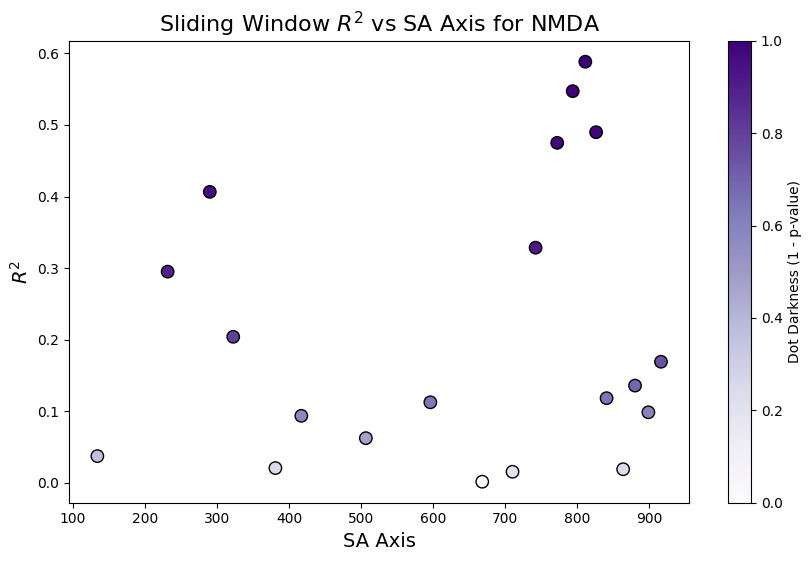

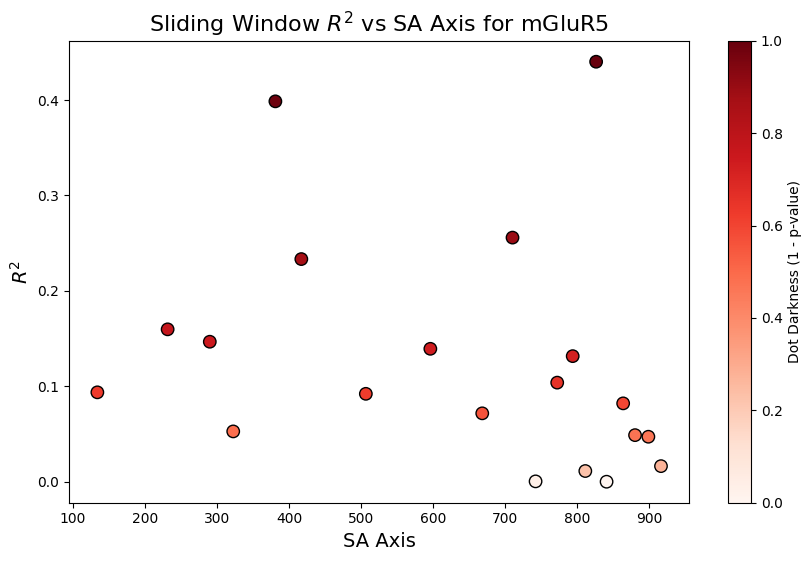

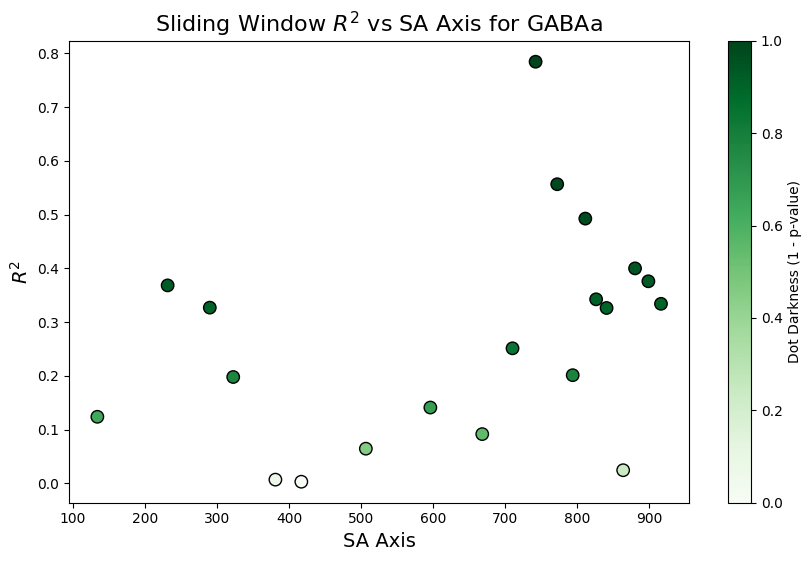

In [26]:
# Sort and reset index for `means_df_all`
means_df_all = means_df_all.sort_values(by="SAaxis_rank", ascending=True)
means_df_all = means_df_all.reset_index(drop=True)

# Initialize results dictionary for all nmaps
results = {nmap: [] for nmap in nmaps}

# Sliding window loop
for start, end in window_indices:
    # Subset the dataframe for the current window
    window_df = means_df_all.iloc[start:end + 1]
    SAavg = window_df["SAaxis_rank"].median()  # Calculate median SAaxis_rank for the window

    for nmap in nmaps:
        # Perform correlation using linregress
        slope, intercept, r_value, p_value, std_err = linregress(
            window_df["GluCEST"], window_df[nmap]
        )
        # Save results for the current window
        results[nmap].append({
            "Window_Start": start,
            "Window_End": end,
            "R_squared": r_value**2,  # Square of the correlation coefficient
            "P_value": p_value,
            "SAaxis_rank": SAavg
        })

# Convert results to DataFrames for each nmap
results_dfs = {nmap: pd.DataFrame(data) for nmap, data in results.items()}

# Plot results for each nmap
for nmap, df in results_dfs.items():
    # x-axis: SA Axis Rank, y-axis: R_squared
    x = df['SAaxis_rank']
    y = df['R_squared']
    p_values = df['P_value']

    # Normalize p-values for dot darkness (smaller p = darker dot)
    dot_darkness = 1 - np.interp(p_values, (p_values.min(), p_values.max()), (0, 1))

    # Create scatter plot
    plt.figure(figsize=(10, 6))
    palette=nmap_palette[nmap]
    scatter = plt.scatter(x, y, c=dot_darkness, cmap=palette, edgecolor='k', s=80)  # Change `cmap` as needed
    plt.colorbar(scatter, label='Dot Darkness (1 - p-value)', orientation='vertical')

    # Add labels and title
    plt.xlabel("SA Axis", fontsize=14)
    plt.ylabel("$R^2$", fontsize=14)
    plt.title(f"Sliding Window $R^2$ vs Median SA Axis Rank for {nmap}", fontsize=16)

    # Show plot
    plt.show()

ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

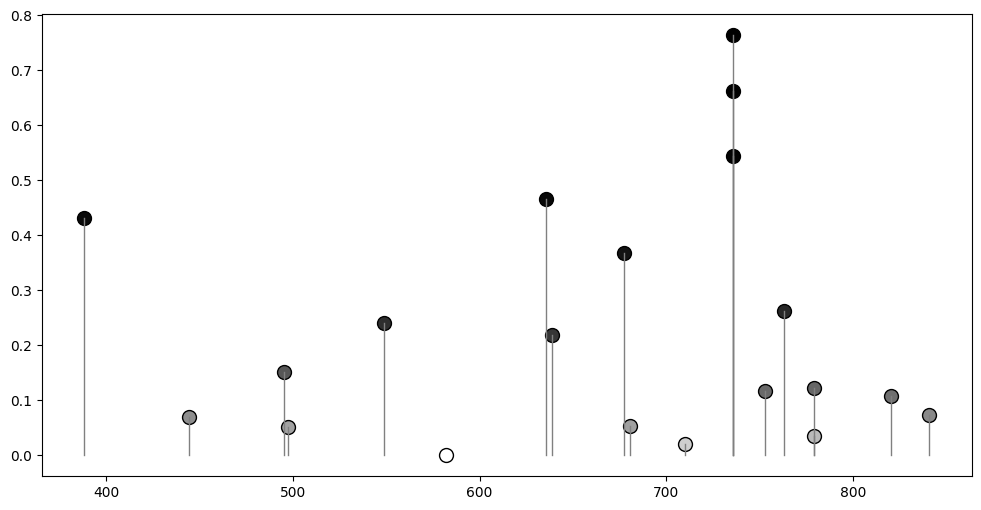

In [53]:
# Normalize p-values to control dot darkness (smaller p = darker dot)
dot_darkness = 1 - np.interp(p_values, (p_values.min(), p_values.max()), (0, 1))

# Create lollipop plot
plt.figure(figsize=(12, 6))
for xi, yi, intensity in zip(x, y, dot_darkness):
    # Add line from x-axis to the dot
    plt.plot([xi, xi], [0, yi], color='gray', linestyle='-', linewidth=1)
    # Add the dot at the top
    plt.scatter(xi, yi, color=plt.cm.Greys(intensity), edgecolor='black', s=100)

# Add colorbar to show p-value intensity
sm = plt.cm.ScalarMappable(cmap='Greys', norm=plt.Normalize(vmin=p_values.min(), vmax=p_values.max()))
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Dot Darkness (1 - p-value)', fontsize=12)

# Add labels and title
plt.xlabel("SA Axis Rank", fontsize=14)
plt.ylabel("$R^2$", fontsize=14)
plt.title("Sliding Window $R^2$ vs SA Axis Rank", fontsize=16)

# Improve layout
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show plot
plt.show()